In [1]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score
from sklearn.metrics import confusion_matrix

In [2]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

TEST_LOCS_KEY = 'test_locs'
TEST_IDS_KEY = 'test_pos_inds'

Reading the file:

In [4]:
filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Reading test file

In [5]:
test_filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_test.npz')
test_data = np.load(test_filepath, allow_pickle=True)
test_locs = test_data[TEST_LOCS_KEY]
test_ids = test_data[TEST_IDS_KEY]

Mapping the taxon ids to taxon latin names: 

In [6]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

Create pandas Dataframe for train data: 

In [7]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data[TRAIN_IDS_KEY]
})
df['taxon_name'] = [species_ids_names[id] for id in data[TRAIN_IDS_KEY].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


Create pandas Dataframe for test data: 

In [8]:
rows = [
    [test_locs[loc_id][0], test_locs[loc_id][1], taxon_id]
    for taxon_id, loc_ids in zip(taxon_ids, test_ids)
    for loc_id in loc_ids
]

In [9]:
test_df = pd.DataFrame(rows, columns=["latitude", "longitude", "taxon_id"])
test_df['taxon_name'] = [species_ids_names[id] for id in test_df["taxon_id"].astype(int)]
test_df.head()

,latitude,longitude,taxon_id,taxon_name
0,-19.884237,126.052979,31529,Lophognathus gilberti
1,-20.219316,124.723953,31529,Lophognathus gilberti
2,-20.053690,125.386505,31529,Lophognathus gilberti
3,-19.973000,126.462440,31529,Lophognathus gilberti
4,-19.962839,124.980362,31529,Lophognathus gilberti


In [10]:
test_df.shape

(1706646, 4)

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [11]:
df = df.dropna(subset=['latitude', 'longitude'])
test_df = test_df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
test_df = test_df[(test_df['latitude'].between(-90, 90)) & (test_df['longitude'].between(-180, 180))]
df.shape, test_df.shape

((272037, 4), (1706646, 4))

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [12]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)
test_df['lat_rounded'] = test_df['latitude'].round(5)
test_df['lon_rounded'] = test_df['longitude'].round(5)

In [13]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', "taxon_id"])
test_df = test_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', "taxon_id"])
df.shape, test_df.shape

((251822, 6), (1706646, 6))

<small>4. Validate species IDs: </small>

In [14]:
df['taxon_id'].isna().sum(), test_df['taxon_id'].isna().sum()

(np.int64(0), np.int64(0))

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [16]:
taxa = pd.read_csv('/Users/Maya/Desktop/species/taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

32140

In [17]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
test_df = test_df[test_df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape, test_df.shape

((162642, 6), (1323320, 6))

<small>6. Convert to categorical labels:</small>

In [18]:
le = LabelEncoder()
le.fit(pd.concat([df['taxon_id'], test_df['taxon_id']]))
df['label'] = le.transform(df['taxon_id'])
test_df['label'] = le.transform(test_df['taxon_id'])

<small>7. Append the climate data</small>

In [28]:
# Since the averaged climate variables are already preprocessed,
# we skip all rasterio steps and load directly from the cleaned CSVs.

import pandas as pd

# 1. Load cleaned test dataset (already includes climate variables)
test_df = pd.read_csv('/Users/Maya/Desktop/test_bird_species_rerun_with_averaged_climate.csv')

# 2. Load reference dataset to ensure consistent species and structure
df = pd.read_csv('/Users/Maya/Desktop/Rasterio final data downloaded from haya/bird_species_with_climate.csv')

# keep only species that exist in training
valid_species = set(df["taxon_id"].unique())
test_df = test_df[test_df["taxon_id"].isin(valid_species)]

# 3. Drop duplicates or missing climate values if any
test_df = test_df.dropna(subset=["Tmin_avg", "Tmax_avg", "Prec_avg"])
test_df = test_df.drop_duplicates(subset=["latitude", "longitude", "taxon_id"])

# 4. Verify structure
print("Test data loaded and verified.")
print("Shape:", test_df.shape)
print("Columns:", list(test_df.columns))
print("Unique bird species in test set:", test_df["taxon_id"].nunique())

# 5. Define features for model inference
test_features = test_df[["latitude", "longitude", "Tmin_avg", "Tmax_avg", "Prec_avg"]]

Test data loaded and verified.
Shape: (1323320, 10)
Columns: ['latitude', 'longitude', 'taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label', 'Tmin_avg', 'Tmax_avg', 'Prec_avg']
Unique bird species in test set: 285


<small>8. Clean the climate data</small>

In [29]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (151391, 10)
Shape without nan data: (150194, 10)


In [32]:
len(test_df)

928354

In [33]:
test_df['Tmin_avg'] = test_df['Tmin_avg'].mask(test_df['Tmin_avg'] < -1e+30, np.nan)
test_df['Tmax_avg'] = test_df['Tmax_avg'].mask(test_df['Tmax_avg'] < -1e+30, np.nan)
test_df['Prec_avg'] = test_df['Prec_avg'].mask(test_df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {test_df.shape}")
test_df = test_df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {test_df.shape}")

Shape with nan data: (928354, 10)
Shape without nan data: (928354, 10)


In [34]:
(df['Tmax_avg'] < df['Tmin_avg']).sum(), (test_df['Tmax_avg'] < test_df['Tmin_avg']).sum()


(np.int64(0), np.int64(0))

<small>9. Split the data to x and y and normalize the climate features</small>

In [35]:
from sklearn.preprocessing import StandardScaler
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
scaler.fit(X_data[climate_features])
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,150194.000000,150194.000000,1.501940e+05,1.501940e+05,1.501940e+05
mean,15.544443,-9.343506,-1.968027e-16,-1.392757e-16,-6.509626e-17
std,32.019650,95.974393,1.000003e+00,1.000003e+00,1.000003e+00
min,-75.284950,-178.060320,-6.684864e+00,-6.659755e+00,-1.640339e+00
25%,-19.905400,-96.408343,-6.481463e-01,-7.715034e-01,-6.507734e-01
50%,27.829345,-47.548143,1.810142e-02,1.161172e-01,-1.759906e-01
75%,41.539592,73.949602,6.747353e-01,7.379541e-01,3.944445e-01
max,72.515430,178.827590,2.290127e+00,2.249082e+00,1.336141e+01


In [36]:
X_test = test_df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_test = test_df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
X_test_scaled = X_test.copy()
X_test_scaled[climate_features] = scaler.transform(X_test[climate_features])
X_test_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
count,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000
mean,13.171677,13.497898,0.217044,0.323857,0.005580
std,29.127638,77.380268,1.436969,1.412912,1.256942
min,-85.600830,-179.933670,-6.914783,-7.159502,-1.640339
25%,-12.422070,-59.177242,-0.761790,-0.656846,-0.920339
50%,11.103984,23.309443,0.656703,0.896294,-0.341208
75%,38.710465,74.511734,1.394146,1.377530,0.615314
max,82.845260,179.994780,2.635286,2.399846,12.253581


Split the data into train and validation sets

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

loading again the split 

In [38]:
X_train = pd.read_csv("X_train.csv")
X_val   = pd.read_csv("X_val.csv")
y_train = pd.read_csv("y_train.csv")
y_val   = pd.read_csv("y_val.csv")

y_train = y_train.values.ravel()
y_val   = y_val.values.ravel()

print("Train/Val data loaded successfully!")
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}")

Train/Val data loaded successfully!
X_train: (120155, 5), X_val: (30039, 5)
y_train: (120155,), y_val: (30039,)


Random forest (training for 1 vs all)

In [40]:
# Train one Random Forest per bird species to predict its presence (1) vs absence (0)
# using climatic + spatial variables. Displays scientific species names for clarity.

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

#1️. Create a mapping between label IDs and species names
# Ensure 'bird_species_with_climate.csv' has 'label' and 'taxon_name' columns
df_climate = pd.read_csv('/Users/Maya/Desktop/Rasterio final data downloaded from haya/bird_species_with_climate.csv')
species_map = dict(zip(df_climate["label"], df_climate["taxon_name"]))

#2️. Prepare training DataFrame
df_train = X_train.copy()
df_train["label"] = y_train

# Get unique species IDs
species_list = np.unique(y_train)
results = []

#3. Train binary models per species
for sp in species_list:
    species_name = species_map.get(sp, f"Species {sp}")  # fallback if name not found
    print(f"\nTraining binary model for species: {species_name} ...")

    # Binary target: 1 if this species, else 0
    df_train["target"] = (df_train["label"] == sp).astype(int)
    X_tr = df_train.drop(columns=["label", "target"])
    y_tr = df_train["target"]

    # Lightweight Random Forest (optimized to prevent kernel crash)
    rf = RandomForestClassifier(
        n_estimators=60,
        max_depth=18,
        min_samples_leaf=3,
        class_weight='balanced',
        n_jobs=2,
        random_state=42
    )

    rf.fit(X_tr, y_tr)

    # Validation
    X_v = X_val
    y_v = (y_val == sp).astype(int)
    y_pred = rf.predict(X_v)
    y_proba = rf.predict_proba(X_v)[:, 1]

    f1  = f1_score(y_v, y_pred)
    auc = roc_auc_score(y_v, y_proba)

    print(f"Trained {species_name} — AUC: {auc:.3f}")

    # Store metrics + model
    results.append({
        "species_id": sp,
        "species_name": species_name,
        "f1_score": f1,
        "auc": auc,
        "model": rf
    })

#4. Combine results
results_df = pd.DataFrame(results)
print("\n Model training completed for all species!")
print(f"Total models trained: {len(results_df)}")
print(results_df[["species_name", "f1_score", "auc"]].head())



Training binary model for species: Aramides saracura ...
Trained Aramides saracura — AUC: 0.924

Training binary model for species: Aramides ypecaha ...
Trained Aramides ypecaha — AUC: 0.956

Training binary model for species: Fulica cristata ...
Trained Fulica cristata — AUC: 0.981

Training binary model for species: Tetraogallus tibetanus ...
Trained Tetraogallus tibetanus — AUC: 1.000

Training binary model for species: Alectoris barbara ...
Trained Alectoris barbara — AUC: 1.000

Training binary model for species: Gallus sonneratii ...
Trained Gallus sonneratii — AUC: 0.957

Training binary model for species: Bonasa umbellus ...
Trained Bonasa umbellus — AUC: 0.986

Training binary model for species: Tetrao urogallus ...
Trained Tetrao urogallus — AUC: 0.992

Training binary model for species: Tympanuchus pallidicinctus ...
Trained Tympanuchus pallidicinctus — AUC: 1.000

Training binary model for species: Ptilopachus petrosus ...
Trained Ptilopachus petrosus — AUC: 0.849

Trainin

In [41]:
#Model sanity check
#Because of AUC being high so wanted to check if everything works well or not

import numpy as np

# 1. Check for overlapping coordinates between train and validation
shared_coords = set(map(tuple, X_train[['latitude', 'longitude']].values)) & set(map(tuple, X_val[['latitude', 'longitude']].values))
print(f" Overlapping coordinates between train & val: {len(shared_coords)}")

# 2. Check class balance for last trained species
print("\nClass distribution for last trained species (target column):")
print(df_train['target'].value_counts())

# 3. Summarize AUC performance across all species
print("\nAUC summary across all species:")
print(results_df["auc"].describe())

# Show top and bottom species by AUC
print("\nTop 5 species by AUC:")
print(results_df.sort_values("auc", ascending=False).head()[["species_name", "auc"]])

print("\nBottom 5 species by AUC:")
print(results_df.sort_values("auc", ascending=True).head()[["species_name", "auc"]])


 Overlapping coordinates between train & val: 0

Class distribution for last trained species (target column):
target
0    120089
1        66
Name: count, dtype: int64

AUC summary across all species:
count    285.000000
mean       0.961885
std        0.042878
min        0.686008
25%        0.949457
50%        0.974880
75%        0.990761
max        1.000000
Name: auc, dtype: float64

Top 5 species by AUC:
               species_name       auc
104      Phrygilus atriceps  1.000000
28    Phoebetria palpebrata  0.999988
281             Urile urile  0.999981
79      Dicrurus forficatus  0.999981
202  Pygoscelis antarcticus  0.999972

Bottom 5 species by AUC:
             species_name       auc
75          Artamus minor  0.686008
227  Carterornis leucotis  0.746221
18      Columba leuconota  0.799274
280     Neophedina cincta  0.821988
200     Crypturellus soui  0.826660


Top 10 performing species for validation


Top 10 Performing Bird Species:
                   species_name  f1_score       auc
104          Phrygilus atriceps  0.977778  1.000000
79          Dicrurus forficatus  0.962963  0.999981
283          Riccordia ricordii  0.952381  0.999969
3        Tetraogallus tibetanus  0.923077  0.999967
25          Spheniscus demersus  0.893130  0.999751
202      Pygoscelis antarcticus  0.892857  0.999972
28        Phoebetria palpebrata  0.888889  0.999988
131          Turdus rufitorques  0.871795  0.999908
8    Tympanuchus pallidicinctus  0.857143  0.999860
275       Theristicus branickii  0.851064  0.999950


/var/folders/h0/0kms8dqj2q3_fm6zm8kf0kdw0000gq/T/ipykernel_82717/2775155637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y="species_name", x="f1_score", data=top10_species, palette="crest")


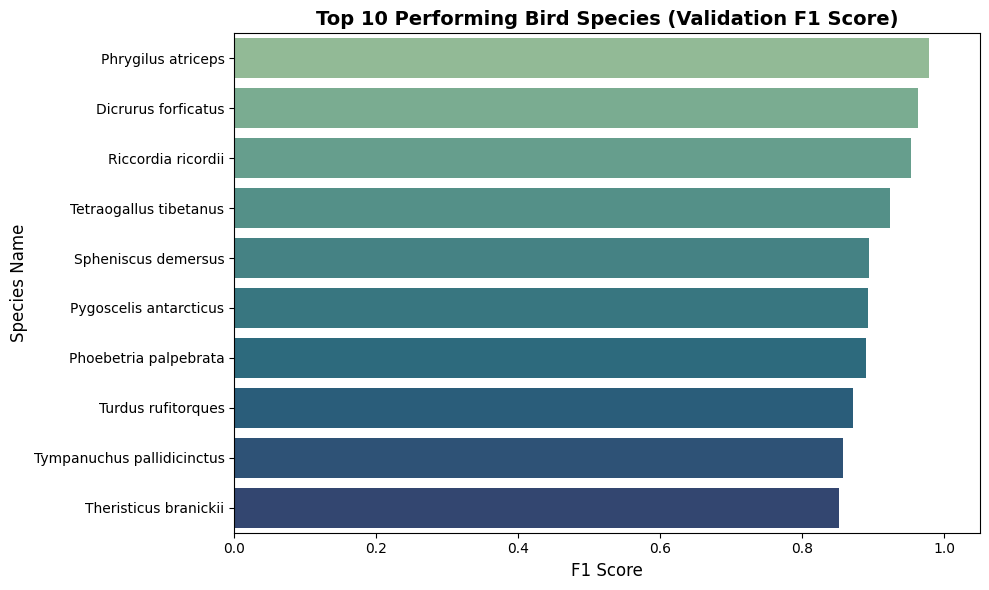

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

top10_species = results_df.sort_values("f1_score", ascending=False).head(10)
print("\nTop 10 Performing Bird Species:")
print(top10_species[["species_name", "f1_score", "auc"]])

plt.figure(figsize=(10, 6))
barplot = sns.barplot(y="species_name", x="f1_score", data=top10_species, palette="crest")
plt.title("Top 10 Performing Bird Species (Validation F1 Score)", fontsize=14, weight="bold")
plt.xlabel("F1 Score", fontsize=12)
plt.ylabel("Species Name", fontsize=12)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

Random location based prediction (need to see how to cross verify)


 Top 5 Predicted Bird Species for Oxford, UK:
            species_name  probability
257    Falco tinnunculus     0.210676
128        Turdus merula     0.161227
217  Regulus ignicapilla     0.130359
219        Picus viridis     0.129055
175         Sylvia borin     0.128963


/var/folders/h0/0kms8dqj2q3_fm6zm8kf0kdw0000gq/T/ipykernel_82717/2808713725.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


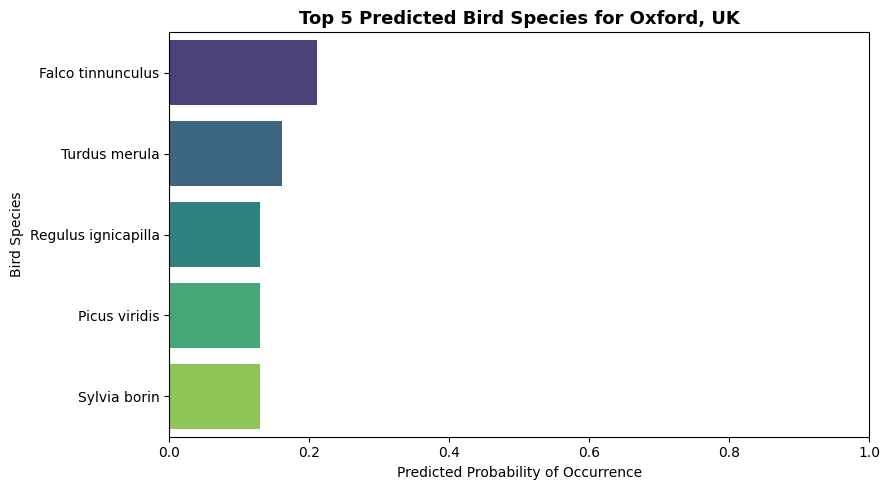

In [43]:
new_location = pd.DataFrame([{
    "latitude": 51.75,        # Oxford latitude
    "longitude": -1.25,       # Oxford longitude
    "Tmin_avg": 4.5,          # °C, average winter minimum
    "Tmax_avg": 14.5,         # °C, average summer maximum
    "Prec_avg": 60.0          # mm, average monthly precipitation
}])

new_location = new_location[["latitude", "longitude", "Tmin_avg", "Tmax_avg", "Prec_avg"]]

# Predict probability for each species using trained Random Forest models
species_probs = {}
for sid, model in zip(results_df["species_id"], results_df["model"]):
    try:
        prob = model.predict_proba(new_location)[0, 1]
        species_probs[sid] = prob
    except Exception as e:
        continue  # just in case any model fails, skip

# probability merge with species name
species_probs_df = pd.DataFrame({
    "species_id": list(species_probs.keys()),
    "probability": list(species_probs.values())
})

species_probs_df = species_probs_df.merge(
    results_df[["species_id", "species_name"]],
    on="species_id",
    how="left"
)

#Sort and display top 5 predicted bird species
top5_predictions = species_probs_df.sort_values("probability", ascending=False).head(5)
print("\n Top 5 Predicted Bird Species for Oxford, UK:")
print(top5_predictions[["species_name", "probability"]])

#Plot results for visual clarity
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))
sns.barplot(
    y="species_name",
    x="probability",
    data=top5_predictions,
    palette="viridis"
)
plt.title("Top 5 Predicted Bird Species for Oxford, UK", fontsize=13, weight="bold")
plt.xlabel("Predicted Probability of Occurrence")
plt.ylabel("Bird Species")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Load and Merge Test Data (birds only)

In [71]:
print(test_df.shape)
print(test_df.columns.tolist())
test_df.head()


(53055, 10)
['latitude', 'longitude', 'taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label', 'Tmin_avg', 'Tmax_avg', 'Prec_avg']


,latitude,longitude,taxon_id,taxon_name,lat_rounded,lon_rounded,label,Tmin_avg,Tmax_avg,Prec_avg
0,19.289352,-89.842890,3117,Patagioenas flavirostris,19.28935,-89.84289,20,18.850333,32.721000,91.750000
1,20.777590,-88.534240,3117,Patagioenas flavirostris,20.77759,-88.53424,20,18.824667,32.724334,103.833333
2,21.513868,-86.804565,3117,Patagioenas flavirostris,21.51387,-86.80457,20,21.658333,30.716667,100.250000
4,21.509193,-88.522995,3117,Patagioenas flavirostris,21.50919,-88.52299,20,19.734470,31.497727,73.250000
5,15.438323,-86.370710,3117,Patagioenas flavirostris,15.43832,-86.37071,20,20.861000,30.976333,95.416667


Test Prediction

In [44]:
test_features = test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]]

proba_matrix = []
species_ids = []

for _, row in results_df.iterrows():
    sp = row["species_id"]
    model = row["model"]
    probs = model.predict_proba(test_features)[:, 1]
    proba_matrix.append(probs)
    species_ids.append(sp)

proba_df = pd.DataFrame(np.array(proba_matrix).T, columns=species_ids)
print("Predicted probabilities for all species on test data.")

Predicted probabilities for all species on test data.


top predicted species for a random test location

In [45]:
sample_idx = np.random.randint(0, len(test_df))
sample_location = test_df.iloc[sample_idx]
lat, lon = sample_location["latitude"], sample_location["longitude"]

species_probs = proba_df.iloc[sample_idx].values
top10_idx = np.argsort(species_probs)[::-1][:10]
top10_species = proba_df.columns[top10_idx]
top10_probs = species_probs[top10_idx]

true_species = sample_location["taxon_id"]

print(f"\nTest location #{sample_idx} (Lat: {lat}, Lon: {lon})")
print("Top 10 predicted bird species:")
for rank, (sp, prob) in enumerate(zip(top10_species, top10_probs), 1):
    check = "✅" if sp == true_species else ""
    print(f"{rank}. Species {sp} — Probability {prob:.4f} {check}")

print(f"\nTrue observed species: {true_species}")


Test location #52899 (Lat: 53.86013, Lon: 25.504534)
Top 10 predicted bird species:
1. Species 118 — Probability 0.1625 
2. Species 257 — Probability 0.1460 
3. Species 128 — Probability 0.1305 
4. Species 34 — Probability 0.1157 
5. Species 33 — Probability 0.1151 
6. Species 175 — Probability 0.1151 
7. Species 142 — Probability 0.0999 
8. Species 129 — Probability 0.0974 
9. Species 100 — Probability 0.0960 
10. Species 29 — Probability 0.0808 

True observed species: 13851


plot


Average F1 across species: 0.314
Average AUC across species: 0.962


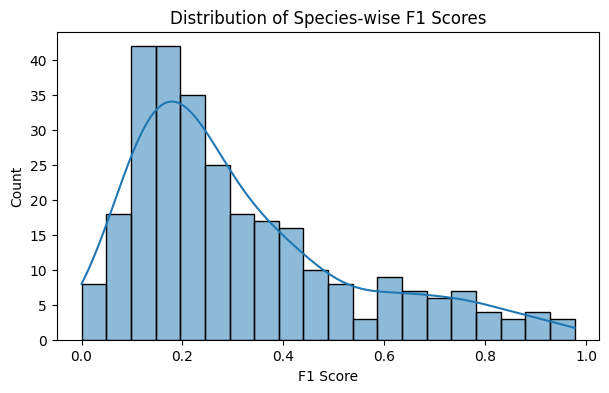

In [46]:
mean_f1 = results_df["f1_score"].mean()
mean_auc = results_df["auc"].mean()
print(f"\nAverage F1 across species: {mean_f1:.3f}")
print(f"Average AUC across species: {mean_auc:.3f}")

plt.figure(figsize=(7,4))
sns.histplot(results_df["f1_score"], bins=20, kde=True)
plt.title("Distribution of Species-wise F1 Scores")
plt.xlabel("F1 Score")
plt.show()

I shall from this point, redo the AUC for test data, to double check, and try to plot it

In [125]:
from sklearn.metrics import roc_auc_score

auc_results = []

for sp in species_list:
    model = results_df.loc[results_df["species_id"] == sp, "model"].iloc[0]
    
    y_true = (y_val == sp).astype(int)
    y_score = model.predict_proba(X_val)[:, 1]
    
    auc_val = roc_auc_score(y_true, y_score)
    
    auc_results.append({
        "species_id": sp,
        "species_name": species_map[sp],
        "auc_val": auc_val,
        "positives": y_true.sum(),
        "negatives": len(y_true) - y_true.sum()
    })

auc_df = pd.DataFrame(auc_results)


In [126]:
macro_auc = auc_df["auc_val"].mean()


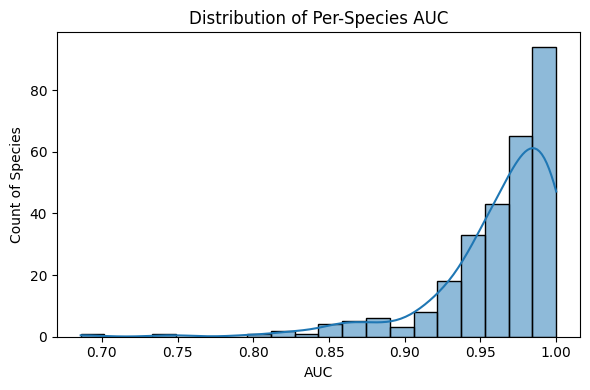

In [127]:
plt.figure(figsize=(6,4))
sns.histplot(auc_df["auc_val"], bins=20, kde=True)
plt.title("Distribution of Per-Species AUC")
plt.xlabel("AUC")
plt.ylabel("Count of Species")
plt.tight_layout()
plt.show()


In [128]:
auc_df.sort_values("auc_val").head(10)
auc_df.sort_values("auc_val", ascending=False).head(10)


,species_id,species_name,auc_val,positives,negatives
104,104,Phrygilus atriceps,1.000000,22,30017
28,28,Phoebetria palpebrata,0.999988,8,30031
281,281,Urile urile,0.999981,9,30030
79,79,Dicrurus forficatus,0.999981,26,30013
202,202,Pygoscelis antarcticus,0.999972,26,30013
283,283,Riccordia ricordii,0.999969,42,29997
3,3,Tetraogallus tibetanus,0.999967,13,30026
275,275,Theristicus branickii,0.999950,20,30019
212,212,Chaetops aurantius,0.999935,11,30028
131,131,Turdus rufitorques,0.999908,36,30003


Now, AUC on Test Data

In [131]:
# Ensure the label column is usable
test_clean = test_df.dropna(subset=["label"]).copy()
test_clean["label"] = test_clean["label"].astype(int)

print("Cleaned test shape:", test_clean.shape)
test_clean.head()


Cleaned test shape: (928354, 10)


,latitude,longitude,taxon_id,taxon_name,lat_rounded,lon_rounded,label,Tmin_avg,Tmax_avg,Prec_avg
0,19.289352,-89.842890,3117,Patagioenas flavirostris,19.28935,-89.84289,20,18.850333,32.721000,91.750000
1,20.777590,-88.534240,3117,Patagioenas flavirostris,20.77759,-88.53424,20,18.824667,32.724334,103.833333
2,21.513868,-86.804565,3117,Patagioenas flavirostris,21.51387,-86.80457,20,21.658333,30.716667,100.250000
4,21.509193,-88.522995,3117,Patagioenas flavirostris,21.50919,-88.52299,20,19.734470,31.497727,73.250000
5,15.438323,-86.370710,3117,Patagioenas flavirostris,15.43832,-86.37071,20,20.861000,30.976333,95.416667


Run these, one at a time

In [132]:
test_features = test_clean[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]]

test_probas = {}

for _, row in results_df.iterrows():
    sp = row["species_id"]
    model = row["model"]
    
    test_probas[sp] = model.predict_proba(test_features)[:, 1]


In [133]:
from sklearn.metrics import roc_auc_score

auc_test_results = []

for sp in species_list:
    y_true = (test_clean["label"] == sp).astype(int)
    y_score = test_probas[sp]
    
    # AUC is undefined if a species has no positives in test set
    if y_true.sum() == 0:
        continue
    
    auc_t = roc_auc_score(y_true, y_score)
    
    auc_test_results.append({
        "species_id": sp,
        "species_name": species_map[sp],
        "auc_test": auc_t,
        "positives": y_true.sum()
    })

auc_test_df = pd.DataFrame(auc_test_results)


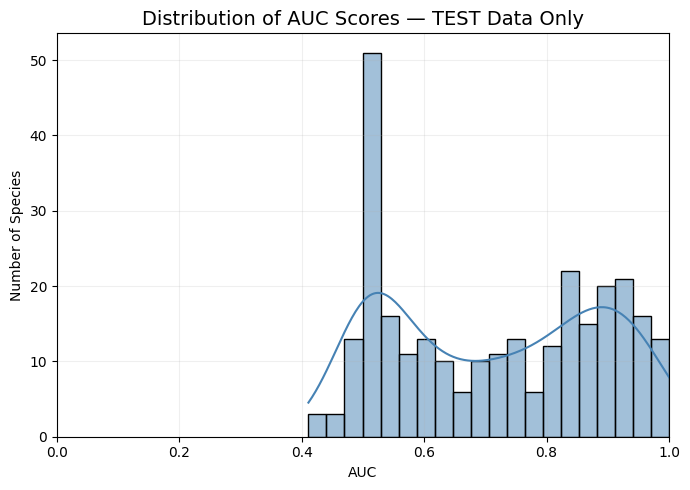

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(auc_test_df["auc_test"], bins=20, kde=True, color="steelblue")

plt.title("Distribution of AUC Scores — TEST Data Only", fontsize=14)
plt.xlabel("AUC")
plt.ylabel("Number of Species")
plt.xlim(0.0, 1.0)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


Let us see if ROC AUC, which is more concerend with "how well the model separates positives from negatives across all thresholds"
ie. Evaluating binary presence / absence discriminationb


In [137]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_v, y_proba)


In [141]:
df_train = X_train.copy()
df_train["label"] = y_train


In [143]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
from joblib import Parallel, delayed

# Prepare NumPy versions for speed
X_train_np = X_train.values          # DataFrame → NumPy
X_val_np   = X_val.values            # DataFrame → NumPy

y_train_np = y_train                 # already NumPy array
y_val_np   = y_val                   # already NumPy array

species_list = np.unique(y_train_np)

# Helper function to train 1 species model
def train_one_species(sp):
    # Binary targets
    y_tr = (y_train_np == sp).astype(int)
    y_v  = (y_val_np   == sp).astype(int)

    # Model
    rf = RandomForestClassifier(
        n_estimators=40,
        max_depth=12,
        min_samples_leaf=3,
        class_weight='balanced',
        n_jobs=-1,        # use all CPU cores
        random_state=42
    )
    
    rf.fit(X_train_np, y_tr)

    # Predictions
    y_pred = rf.predict(X_val_np)
    y_proba = rf.predict_proba(X_val_np)[:, 1]

    # Metrics
    f1  = f1_score(y_v, y_pred)
    acc = (y_pred == y_v).mean()
    auc = roc_auc_score(y_v, y_proba)

    return {
        "species_id": sp,
        "species_name": species_map.get(sp, f"Species {sp}"),
        "f1_score": f1,
        "accuracy": acc,
        "auc": auc,
        "model": rf
    }

# Run all species in parallel
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_one_species)(sp) for sp in species_list
)

results_df = pd.DataFrame(results)

print("Finished training all species.")
print(results_df[["species_name", "f1_score", "accuracy", "auc"]].head())


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    8.0s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   11.9s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:   17.0s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   25.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   32.1s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:   42.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   48.4s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:   59.2s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  2

Finished training all species.
             species_name  f1_score  accuracy       auc
0       Aramides saracura  0.136253  0.988182  0.979355
1        Aramides ypecaha  0.320242  0.992510  0.972524
2         Fulica cristata  0.391499  0.981890  0.989703
3  Tetraogallus tibetanus  0.923077  0.999933  0.999967
4       Alectoris barbara  0.368421  0.999201  0.999674


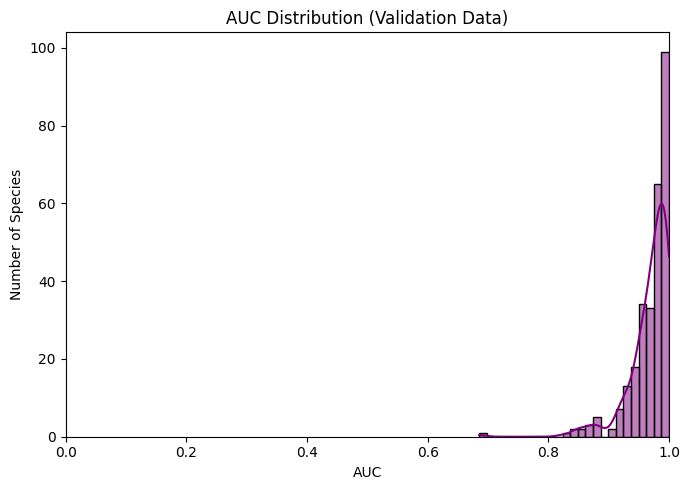

In [144]:
plt.figure(figsize=(7,5))
sns.histplot(results_df["auc"], bins=25, kde=True, color="purple")
plt.title("AUC Distribution (Validation Data)")
plt.xlabel("AUC")
plt.ylabel("Number of Species")
plt.xlim(0,1)
plt.tight_layout()
plt.show()


In [146]:
print("Macro AUC:", results_df["auc"].mean())
print("Macro F1:", results_df["f1_score"].mean())
print("Macro Accuracy:", results_df["accuracy"].mean())


Macro AUC: 0.9687581693339113
Macro F1: 0.2514243422318452
Macro Accuracy: 0.9689297480526777


In [148]:
from sklearn.metrics import roc_auc_score

auc_test_results = []

for sp in results_df["species_id"]:
    y_true = (y_test_np == sp).astype(int)
    y_score = test_probas[sp]

    # Skip species that do not appear in the test set
    if y_true.sum() == 0:
        continue

    auc_t = roc_auc_score(y_true, y_score)

    auc_test_results.append({
        "species_id": sp,
        "species_name": species_map[sp],
        "auc_test": auc_t,
        "positives": int(y_true.sum())
    })

auc_test_df = pd.DataFrame(auc_test_results)
auc_test_df.head()


,species_id,species_name,auc_test,positives
0,0,Aramides saracura,0.503633,593
1,1,Aramides ypecaha,0.694085,2217
2,2,Fulica cristata,0.623746,2877
3,3,Tetraogallus tibetanus,0.869201,685
4,4,Alectoris barbara,0.830549,791


In [149]:
# Ensure labels exist and are integers
test_clean = test_df.dropna(subset=["label"]).copy()
test_clean["label"] = test_clean["label"].astype(int)

X_test_np = test_clean[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].values
y_test_np = test_clean["label"].values


In [150]:
# Dictionary to store probabilities per species
test_probas = {}

for _, row in results_df.iterrows():
    sp = row["species_id"]
    model = row["model"]     # already trained
    test_probas[sp] = model.predict_proba(X_test_np)[:, 1]


In [151]:
from sklearn.metrics import roc_auc_score

auc_test_results = []

for sp in results_df["species_id"]:
    y_true = (y_test_np == sp).astype(int)
    y_score = test_probas[sp]

    # Skip species that do not appear in the test set
    if y_true.sum() == 0:
        continue

    auc_t = roc_auc_score(y_true, y_score)

    auc_test_results.append({
        "species_id": sp,
        "species_name": species_map[sp],
        "auc_test": auc_t,
        "positives": int(y_true.sum())
    })

auc_test_df = pd.DataFrame(auc_test_results)
auc_test_df.head()


,species_id,species_name,auc_test,positives
0,0,Aramides saracura,0.499475,593
1,1,Aramides ypecaha,0.705765,2217
2,2,Fulica cristata,0.738036,2877
3,3,Tetraogallus tibetanus,0.811747,685
4,4,Alectoris barbara,0.523262,791


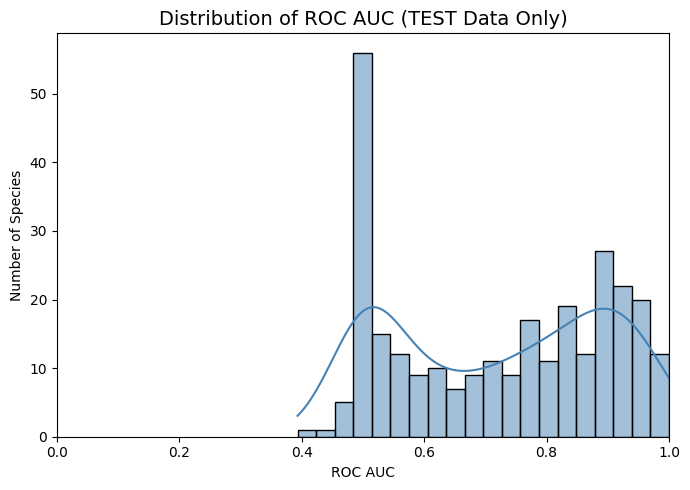

In [152]:
plt.figure(figsize=(7,5))
sns.histplot(auc_test_df["auc_test"], bins=20, kde=True, color="steelblue")

plt.title("Distribution of ROC AUC (TEST Data Only)", fontsize=14)
plt.xlabel("ROC AUC")
plt.ylabel("Number of Species")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


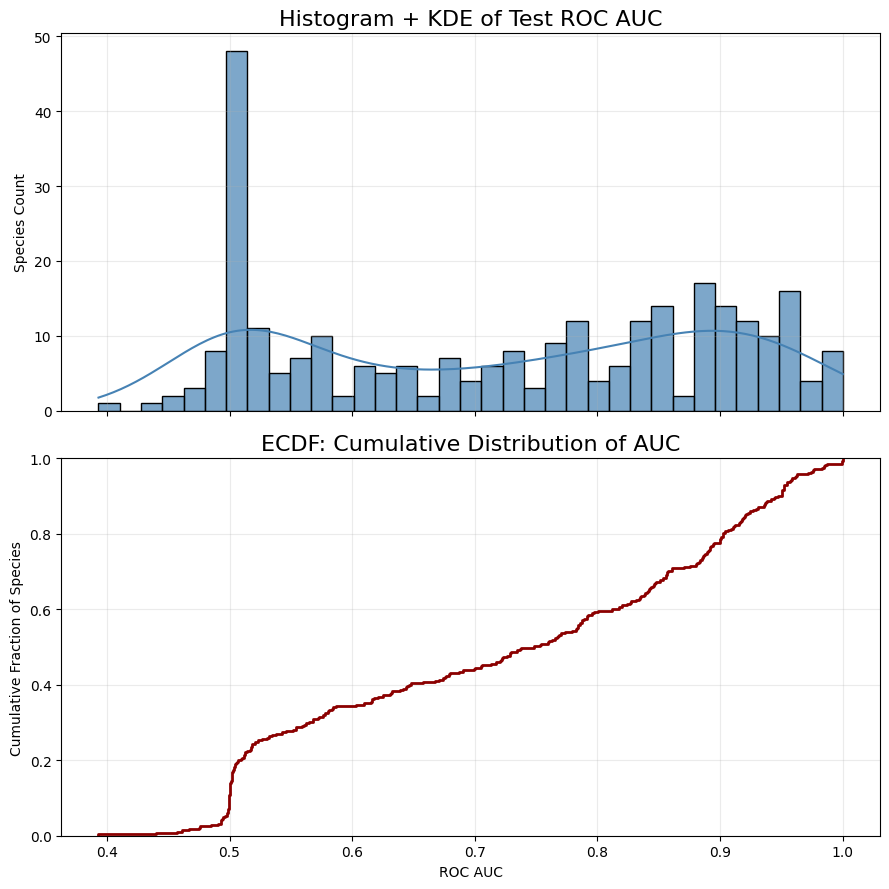

In [153]:
fig, ax = plt.subplots(2, 1, figsize=(9,9), sharex=True)

# Histogram + KDE
sns.histplot(
    auc_test_df["auc_test"],
    bins=35,
    kde=True,
    color="steelblue",
    alpha=0.7,
    ax=ax[0]
)

ax[0].set_title("Histogram + KDE of Test ROC AUC", fontsize=16)
ax[0].set_ylabel("Species Count")
ax[0].grid(alpha=0.25)

# ECDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(
    data=auc_test_df,
    x="auc_test",
    color="darkred",
    linewidth=2,
    ax=ax[1]
)

ax[1].set_title("ECDF: Cumulative Distribution of AUC", fontsize=16)
ax[1].set_xlabel("ROC AUC")
ax[1].set_ylabel("Cumulative Fraction of Species")
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


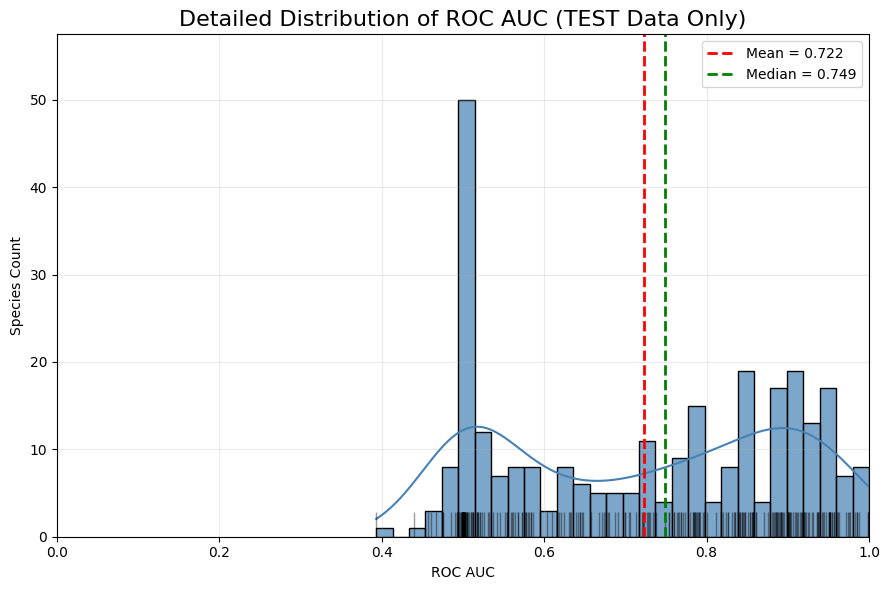

In [155]:
plt.figure(figsize=(9,6))

sns.histplot(
    auc_test_df["auc_test"],
    bins=30,                   # finer detail
    kde=True,
    color="steelblue",
    alpha=0.7
)

# Rugplot to show individual species
sns.rugplot(
    auc_test_df["auc_test"],
    height=0.05,
    color="black",
    alpha=0.4
)

# Mean and median
mean_auc = auc_test_df["auc_test"].mean()
median_auc = auc_test_df["auc_test"].median()

plt.axvline(mean_auc, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_auc:.3f}")
plt.axvline(median_auc, color="green", linestyle="--", linewidth=2, label=f"Median = {median_auc:.3f}")

plt.title("Detailed Distribution of ROC AUC (TEST Data Only)", fontsize=16)
plt.xlabel("ROC AUC")
plt.ylabel("Species Count")
plt.xlim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Trying the Top-k method For Validation

In [50]:
import numpy as np

species_ids = [r["species_id"] for r in results]
species_names = [r["species_name"] for r in results]

# Matrix: rows are validation rows, columns are species probabilities
proba_matrix = np.zeros((len(X_val), len(results)))

for j, r in enumerate(results):
    model = r["model"]
    # Probability that species j is present
    proba_matrix[:, j] = model.predict_proba(X_val)[:, 1]


In [51]:
# Map each species_id to its column index in the probability matrix
id_to_col = {sp: idx for idx, sp in enumerate(species_ids)}

# Convert y_val to column indices
y_true_cols = np.array([id_to_col[y] for y in y_val])


In [52]:
def top_k_accuracy(proba_matrix, true_cols, k):
    # top K species per row (highest probabilities)
    topk = np.argsort(proba_matrix, axis=1)[:, -k:]
    # Check if true species is among them
    return np.mean([
        true_cols[i] in topk[i]
        for i in range(len(true_cols))
    ])


In [53]:
top1 = top_k_accuracy(proba_matrix, y_true_cols, k=1)
top3 = top_k_accuracy(proba_matrix, y_true_cols, k=3)
top5 = top_k_accuracy(proba_matrix, y_true_cols, k=5)

print("Top-1 accuracy:", top1)
print("Top-3 accuracy:", top3)
print("Top-5 accuracy:", top5)


Top-1 accuracy: 0.3370618196344752
Top-3 accuracy: 0.5882685841739073
Top-5 accuracy: 0.7202636572455807


In [55]:
#Top-K “Confusion Matrix” Visualization

# proba_matrix: [num_samples, num_species]
# y_true_cols:  true species index in columns
# species_ids and species_names already defined

# argsort in descending order
ranked = np.argsort(-proba_matrix, axis=1)   # highest prob first

# Find the rank of the correct species
true_ranks = np.array([
    np.where(ranked[i] == y_true_cols[i])[0][0] + 1    # +1 for human-readable rank
    for i in range(len(y_true_cols))
])


In [56]:
K = 10
num_species = len(species_ids)

rank_matrix = np.zeros((num_species, K), dtype=int)

# For each validation sample
for i in range(len(y_true_cols)):
    species_idx = y_true_cols[i]        # row in matrix
    rank = true_ranks[i]                # rank from 1..K
    if rank <= K:                       # ignore worse than top-K
        rank_matrix[species_idx, rank-1] += 1


In [58]:
# Compute median rank per species
median_ranks = np.zeros(num_species)
for s_idx in range(num_species):
    median_ranks[s_idx] = np.median(true_ranks[y_true_cols == s_idx])

# Sort species by how well the model predicts them
order = np.argsort(median_ranks)

rank_matrix_sorted = rank_matrix[order, :]
species_names_sorted = [species_names[i] for i in order]


<Axes: >

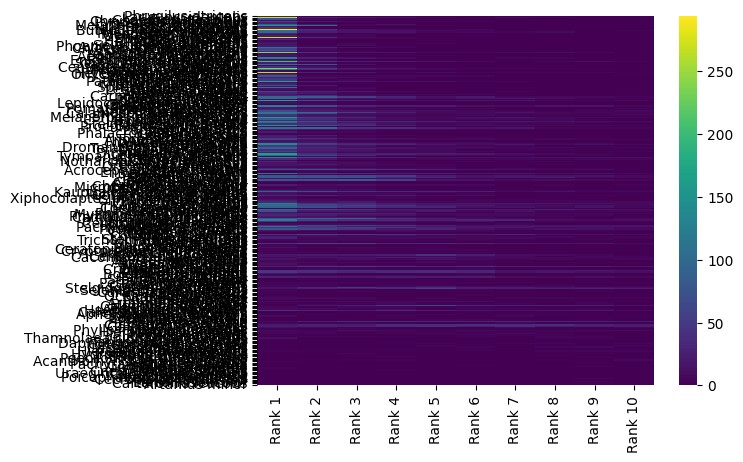

In [59]:
sns.heatmap(
    rank_matrix_sorted,
    cmap="viridis",
    xticklabels=[f"Rank {i}" for i in range(1, K+1)],
    yticklabels=species_names_sorted
)



Trying Top 30 errorsince top K is too spidery

In [70]:
# ranked: [num_samples, num_species] indices sorted from highest probability to lowest
# true_ranks: [num_samples] where each value is 1, 2, 3, ... (rank of the true species)

# If you don't have it yet:
ranked = np.argsort(-proba_matrix, axis=1)
true_ranks = np.array([
    np.where(ranked[i] == y_true_cols[i])[0][0] + 1
    for i in range(len(y_true_cols))
])


In [71]:
top30_errors = []

for s_idx, s_id in enumerate(species_ids):
    mask = (y_true_cols == s_idx)
    ranks = true_ranks[mask]

    error_rate = np.mean(ranks > 30)

    top30_errors.append({
        "species_id": s_id,
        "species_name": species_names[s_idx],
        "count": len(ranks),
        "top30_error_rate": error_rate
    })

top30_error_df = pd.DataFrame(top30_errors)


In [72]:
top30_error_df = top30_error_df.sort_values("top30_error_rate", ascending=False)
print(top30_error_df.head(15))   # worst species
print(top30_error_df.tail(15))   # best species


     species_id                   species_name  count  top30_error_rate
75           75                  Artamus minor      8          0.625000
227         227           Carterornis leucotis      8          0.500000
18           18              Columba leuconota     10          0.400000
280         280              Neophedina cincta     12          0.333333
27           27            Oceanites oceanicus      9          0.333333
68           68            Malcorus pectoralis     10          0.300000
9             9           Ptilopachus petrosus     10          0.300000
78           78              Laniarius bicolor      7          0.285714
121         121  Acanthorhynchus superciliosus     15          0.266667
130         130              Turdus albicollis     15          0.266667
57           57              Lophornis ornatus      8          0.250000
282         282         Chrysuronia versicolor     20          0.250000
252         252          Psilopogon zeylanicus     27          0

/var/folders/h0/0kms8dqj2q3_fm6zm8kf0kdw0000gq/T/ipykernel_82717/671758379.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


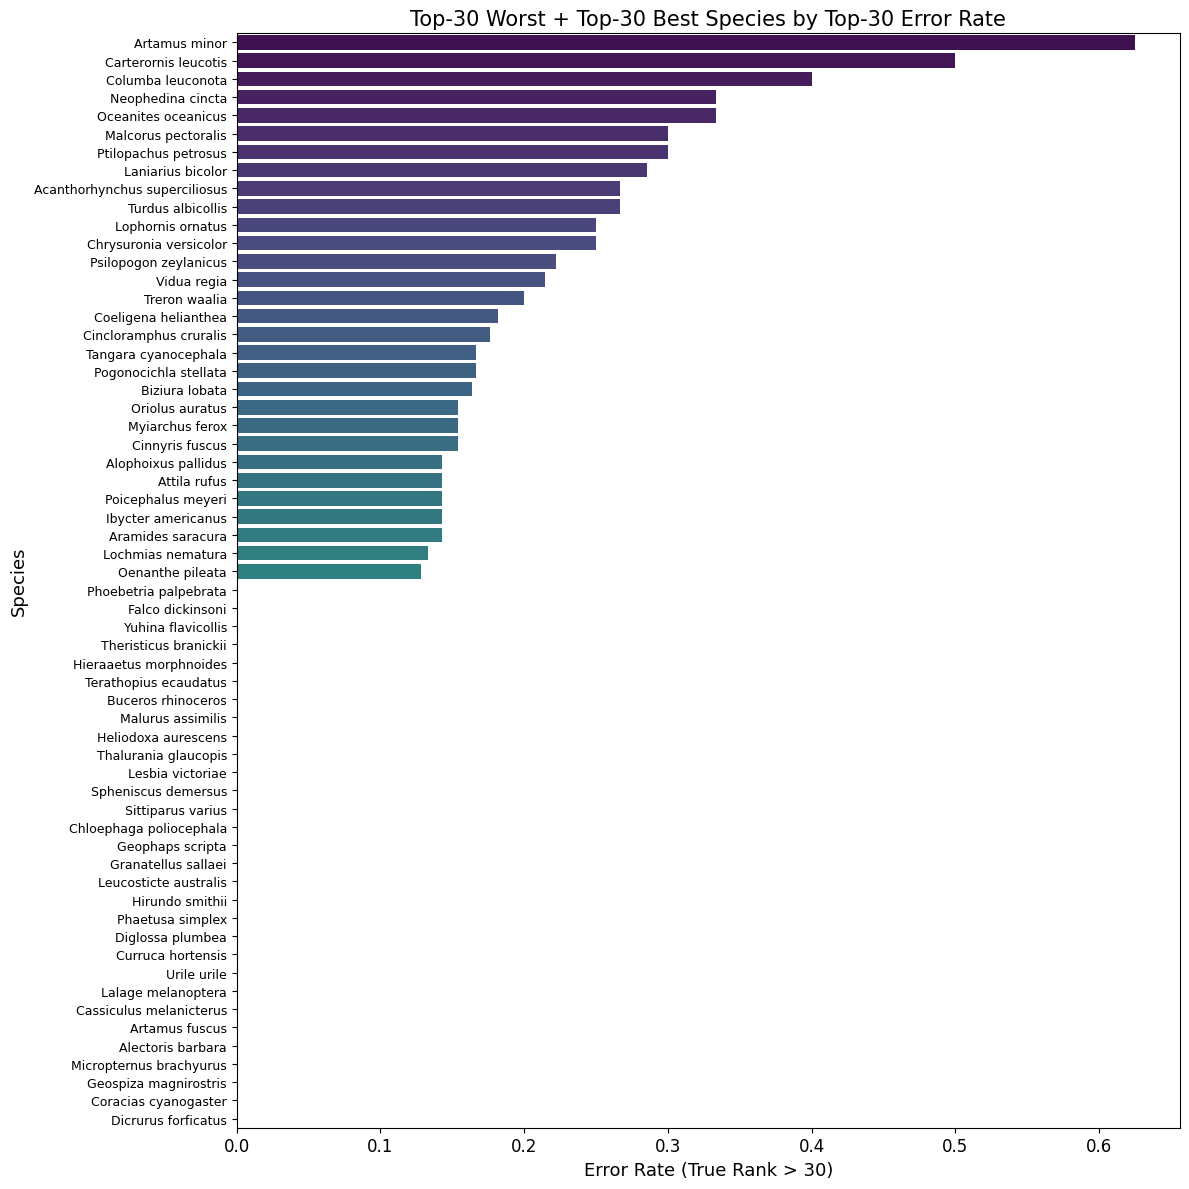

In [75]:
# Take the worst 30 species (highest error)
worst30 = top30_error_df.sort_values("top30_error_rate", ascending=False).head(30)

# Take the best 30 species (lowest error)
best30 = top30_error_df.sort_values("top30_error_rate", ascending=True).head(30)

# Combine them for plotting
subset = pd.concat([worst30, best30], ignore_index=True)

plt.figure(figsize=(12, 12))

sns.barplot(
    data=subset,
    y="species_name",
    x="top30_error_rate",
    palette="viridis"
)

plt.title("Top-30 Worst + Top-30 Best Species by Top-30 Error Rate", fontsize=15)
plt.xlabel("Error Rate (True Rank > 30)", fontsize=13)
plt.ylabel("Species", fontsize=13)

plt.yticks(fontsize=9)
plt.xticks(fontsize=12)

plt.tight_layout()
plt.show()


In [156]:
species_ids = np.array(proba_df.columns)   # species IDs (labels)
label_to_index = {sp: i for i, sp in enumerate(species_ids)}


In [157]:
true_species_labels = test_clean["label"].values
true_indices = np.array([label_to_index[lab] for lab in true_species_labels])


In [158]:
proba_matrix = proba_df.values   # shape: N_test × N_species

# argsort in descending order (best first)
ranked = np.argsort(-proba_matrix, axis=1)


In [159]:
def top_k_accuracy(ranked, true_indices, k):
    hits = [
        true_indices[i] in ranked[i, :k]
        for i in range(len(true_indices))
    ]
    return np.mean(hits)


In [160]:
topk_results = {}

for k in [1, 3, 5, 10, 20, 30, 50]:
    topk_results[k] = top_k_accuracy(ranked, true_indices, k)

topk_results


{1: np.float64(0.04217895328721587),
 3: np.float64(0.10652401993205178),
 5: np.float64(0.16768172485926705),
 10: np.float64(0.3208151200942744),
 20: np.float64(0.5144255316398701),
 30: np.float64(0.619750655461171),
 50: np.float64(0.7017797090334075)}

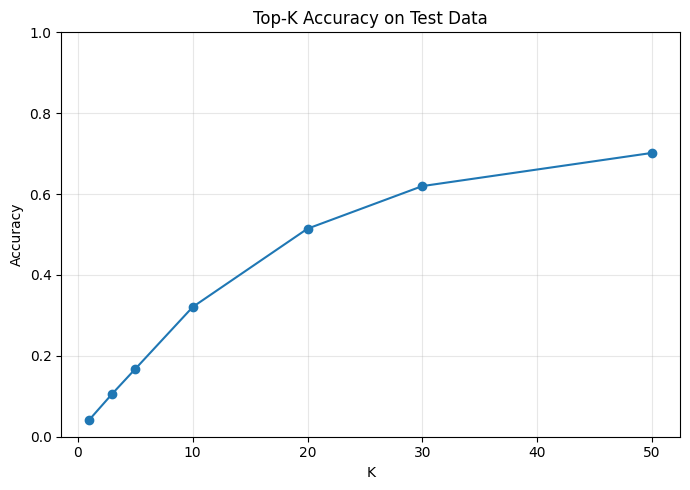

In [161]:
plt.figure(figsize=(7,5))
ks = list(topk_results.keys())
vals = [topk_results[k] for k in ks]

plt.plot(ks, vals, marker='o')
plt.title("Top-30 Accuracy on Test Data")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Now we do the False Negative Rate: how often locations that are known to be positive, was predicted to be negative

In [77]:
fnr_list = []

for s_idx, s_id in enumerate(species_ids):
    mask = (y_true_cols == s_idx)
    ranks = true_ranks[mask]

    # False negative = true species NOT ranked #1
    fnr = np.mean(ranks != 1)

    fnr_list.append({
        "species_id": s_id,
        "species_name": species_names[s_idx],
        "count": len(ranks),
        "false_negative_rate": fnr
    })

fnr_df = pd.DataFrame(fnr_list).sort_values("false_negative_rate", ascending=False)


In [80]:
print(fnr_df.head(30))


     species_id                species_name  count  false_negative_rate  \
284         284          Campocolinus coqui     16             1.000000   
52           52           Phaethornis ruber     16             1.000000   
183         183  Poecilotriccus plumbeiceps      9             1.000000   
35           35            Falco dickinsoni      8             1.000000   
187         187           Campethera nubica     16             1.000000   
191         191   Poicephalus cryptoxanthus     15             1.000000   
92           92         Euphonia pectoralis     24             1.000000   
235         235           Turdus simillimus      8             1.000000   
232         232       Cecropis senegalensis     12             1.000000   
195         195    Hydropsalis climacocerca     10             1.000000   
255         255         Stomiopera unicolor     14             1.000000   
227         227        Carterornis leucotis      8             1.000000   
201         201    Cryptu

/var/folders/h0/0kms8dqj2q3_fm6zm8kf0kdw0000gq/T/ipykernel_82717/4194916710.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


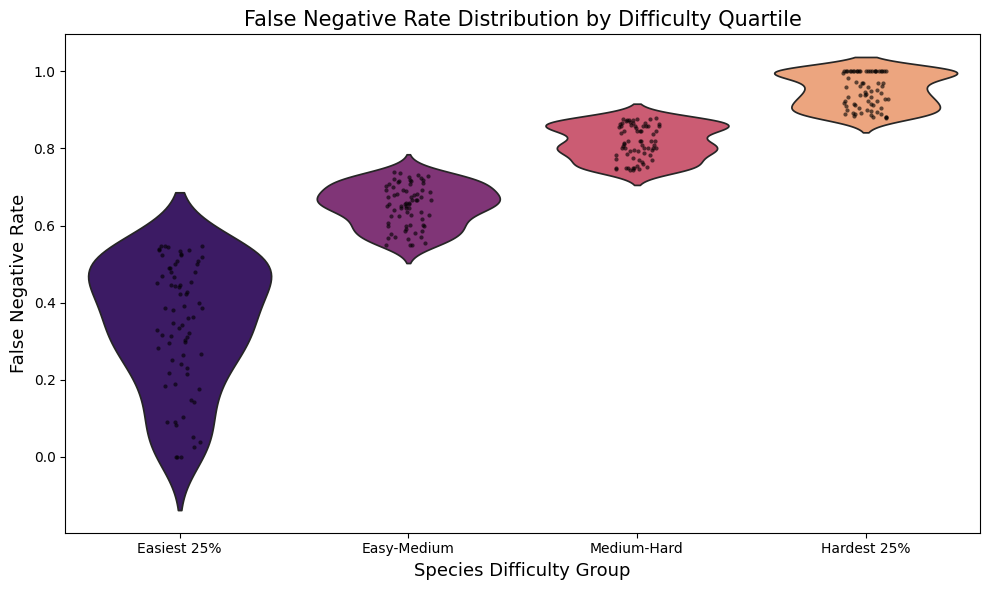

In [79]:
fnr_df["quartile"] = pd.qcut(
    fnr_df["false_negative_rate"],
    q=4,
    labels=["Easiest 25%", "Easy-Medium", "Medium-Hard", "Hardest 25%"]
)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=fnr_df,
    x="quartile",
    y="false_negative_rate",
    inner=None,
    palette="magma"
)

sns.stripplot(
    data=fnr_df,
    x="quartile",
    y="false_negative_rate",
    color="black",
    size=3,
    alpha=0.6
)

plt.title("False Negative Rate Distribution by Difficulty Quartile", fontsize=15)
plt.xlabel("Species Difficulty Group", fontsize=13)
plt.ylabel("False Negative Rate", fontsize=13)
plt.tight_layout()
plt.show()


We trying false negative rate again

In [115]:
predicted_species = proba_df.idxmax(axis=1).values
true_species = test_df["taxon_id"].values

In [116]:
correct = (predicted_species == true_species)

TP = np.sum(correct)          # correct predictions
FN = np.sum(~correct)         # incorrect predictions

FNR = FN / (TP + FN)

print("False Negative Rate on TEST set:", FNR)


False Negative Rate on TEST set: 1.0


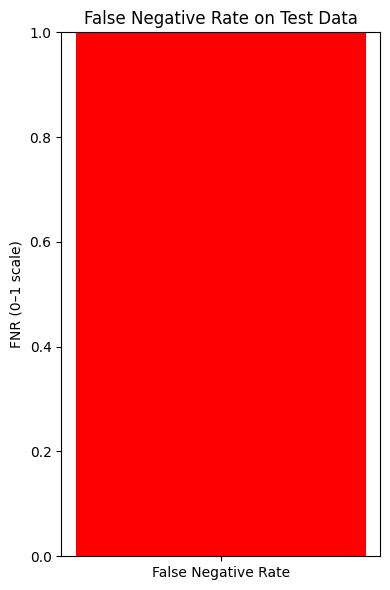

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 6))
plt.bar(["False Negative Rate"], [FNR], color="red")
plt.ylim(0, 1)
plt.title("False Negative Rate on Test Data")
plt.ylabel("FNR (0–1 scale)")
plt.tight_layout()
plt.show()


In [119]:
set(species_list).intersection(set(test_df["taxon_id"].unique()))


set()

False Negative rate is bad, according to chatgpt, it is beacuse 
Your one-vs-all binary models never learned how to rank species 20 above all other species in the multi-class prediction stage.

Mean Reciprocal Rank (MRR)
“Do we usually put the right bird in the top few positions,
or does it end up deep in the list?”

In [154]:
import numpy as np

# Convert to NumPy for speed
proba_matrix = proba_df.values

# For each test point, get ranking of species (highest score first)
ranked = np.argsort(-proba_matrix, axis=1)

# True labels mapped to the same order as species_ids
species_ids = np.array(proba_df.columns)
label_to_index = {sp: i for i, sp in enumerate(species_ids)}

true_idx = np.array([label_to_index[lab] for lab in test_clean["label"]])

# Compute reciprocal rank per test example
reciprocal_ranks = []

for i in range(len(true_idx)):
    # find where true species appears in ranking
    rank_of_true = np.where(ranked[i] == true_idx[i])[0][0] + 1  # +1 = rank starting at 1
    reciprocal_ranks.append(1 / rank_of_true)

MRR = np.mean(reciprocal_ranks)
print("Mean Reciprocal Rank:", MRR)
print("Typical rank of true species:", 1 / MRR)


Mean Reciprocal Rank: 0.12524211743389319
Typical rank of true species: 7.98453444008428


We try the "Recall" Validation now

In [120]:
print(df_climate.columns)


Index(['latitude', 'longitude', 'taxon_id', 'taxon_name', 'lat_rounded',
       'lon_rounded', 'label', 'Tmin_avg', 'Tmax_avg', 'Prec_avg'],
      dtype='object')


In [121]:
df_climate[["label", "taxon_name"]].head()

,label,taxon_name
0,20,Patagioenas flavirostris
1,20,Patagioenas flavirostris
2,20,Patagioenas flavirostris
3,20,Patagioenas flavirostris
4,20,Patagioenas flavirostris


In [122]:
test_df["taxon_id"].head()


0    3117
1    3117
2    3117
4    3117
5    3117
Name: taxon_id, dtype: int64

In [124]:
test_df.head()

,latitude,longitude,taxon_id,taxon_name,lat_rounded,lon_rounded,label,Tmin_avg,Tmax_avg,Prec_avg
0,19.289352,-89.842890,3117,Patagioenas flavirostris,19.28935,-89.84289,20,18.850333,32.721000,91.750000
1,20.777590,-88.534240,3117,Patagioenas flavirostris,20.77759,-88.53424,20,18.824667,32.724334,103.833333
2,21.513868,-86.804565,3117,Patagioenas flavirostris,21.51387,-86.80457,20,21.658333,30.716667,100.250000
4,21.509193,-88.522995,3117,Patagioenas flavirostris,21.50919,-88.52299,20,19.734470,31.497727,73.250000
5,15.438323,-86.370710,3117,Patagioenas flavirostris,15.43832,-86.37071,20,20.861000,30.976333,95.416667


In [40]:
# Train one Random Forest per bird species to predict its presence (1) vs absence (0)
# using climatic + spatial variables. Displays scientific species names for clarity.

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

#1️. Create a mapping between label IDs and species names
# Ensure 'bird_species_with_climate.csv' has 'label' and 'taxon_name' columns
df_climate = pd.read_csv('/Users/Maya/Desktop/Rasterio final data downloaded from haya/bird_species_with_climate.csv')
species_map = dict(zip(df_climate["label"], df_climate["taxon_name"]))

#2️. Prepare training DataFrame
df_train = X_train.copy()
df_train["label"] = y_train

# Get unique species IDs
species_list = np.unique(y_train)
results = []

#3. Train binary models per species
for sp in species_list:
    species_name = species_map.get(sp, f"Species {sp}")  # fallback if name not found
    print(f"\nTraining binary model for species: {species_name} ...")

    # Binary target: 1 if this species, else 0
    df_train["target"] = (df_train["label"] == sp).astype(int)
    X_tr = df_train.drop(columns=["label", "target"])
    y_tr = df_train["target"]

    # Lightweight Random Forest (optimized to prevent kernel crash)
    rf = RandomForestClassifier(
        n_estimators=60,
        max_depth=18,
        min_samples_leaf=3,
        class_weight='balanced',
        n_jobs=2,
        random_state=42
    )

    rf.fit(X_tr, y_tr)

    # Validation
    X_v = X_val
    y_v = (y_val == sp).astype(int)
    y_pred = rf.predict(X_v)
    y_proba = rf.predict_proba(X_v)[:, 1]

    f1  = f1_score(y_v, y_pred)
    auc = roc_auc_score(y_v, y_proba)

    print(f"Trained {species_name} — AUC: {auc:.3f}")

    # Store metrics + model
    results.append({
        "species_id": sp,
        "species_name": species_name,
        "f1_score": f1,
        "auc": auc,
        "model": rf
    })

#4. Combine results
results_df = pd.DataFrame(results)
print("\n Model training completed for all species!")
print(f"Total models trained: {len(results_df)}")
print(results_df[["species_name", "f1_score", "auc"]].head())



Training binary model for species: Aramides saracura ...
Trained Aramides saracura — AUC: 0.924

Training binary model for species: Aramides ypecaha ...
Trained Aramides ypecaha — AUC: 0.956

Training binary model for species: Fulica cristata ...
Trained Fulica cristata — AUC: 0.981

Training binary model for species: Tetraogallus tibetanus ...
Trained Tetraogallus tibetanus — AUC: 1.000

Training binary model for species: Alectoris barbara ...
Trained Alectoris barbara — AUC: 1.000

Training binary model for species: Gallus sonneratii ...
Trained Gallus sonneratii — AUC: 0.957

Training binary model for species: Bonasa umbellus ...
Trained Bonasa umbellus — AUC: 0.986

Training binary model for species: Tetrao urogallus ...
Trained Tetrao urogallus — AUC: 0.992

Training binary model for species: Tympanuchus pallidicinctus ...
Trained Tympanuchus pallidicinctus — AUC: 1.000

Training binary model for species: Ptilopachus petrosus ...
Trained Ptilopachus petrosus — AUC: 0.849

Trainin

In [81]:
predicted_cols = ranked[:, 0]  # the species ranked #1 by the model


In [82]:
recall_list = []

for s_idx, s_id in enumerate(species_ids):
    # Samples where the true species = S
    true_mask = (y_true_cols == s_idx)

    # For those samples, how many were predicted correctly?
    TP = np.sum(predicted_cols[true_mask] == s_idx)
    FN = np.sum(predicted_cols[true_mask] != s_idx)

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    recall_list.append({
        "species_id": s_id,
        "species_name": species_names[s_idx],
        "TP": TP,
        "FN": FN,
        "count": TP + FN,
        "recall": recall
    })

recall_df = pd.DataFrame(recall_list)


In [83]:
recall_df.sort_values("recall").head(10)


,species_id,species_name,TP,FN,count,recall
284,284,Campocolinus coqui,0,16,16,0.0
184,184,Cnemotriccus fuscatus,0,9,9,0.0
187,187,Campethera nubica,0,16,16,0.0
243,243,Lalage melanoptera,0,14,14,0.0
92,92,Euphonia pectoralis,0,24,24,0.0
35,35,Falco dickinsoni,0,8,8,0.0
191,191,Poicephalus cryptoxanthus,0,15,15,0.0
195,195,Hydropsalis climacocerca,0,10,10,0.0
82,82,Tchagra australis,0,28,28,0.0
235,235,Turdus simillimus,0,8,8,0.0


In [84]:
recall_df.sort_values("recall", ascending=False).head(10)


,species_id,species_name,TP,FN,count,recall
79,79,Dicrurus forficatus,26,0,26,1.000000
104,104,Phrygilus atriceps,22,0,22,1.000000
28,28,Phoebetria palpebrata,8,0,8,1.000000
283,283,Riccordia ricordii,41,1,42,0.976190
202,202,Pygoscelis antarcticus,25,1,26,0.961538
275,275,Theristicus branickii,19,1,20,0.950000
131,131,Turdus rufitorques,33,3,36,0.916667
264,264,Sittiparus varius,80,8,88,0.909091
212,212,Chaetops aurantius,10,1,11,0.909091
25,25,Spheniscus demersus,112,13,125,0.896000


In [86]:
predicted_cols = ranked[:, 0]

recall_list = []
for s_idx, s_id in enumerate(species_ids):
    true_mask = (y_true_cols == s_idx)

    TP = np.sum(predicted_cols[true_mask] == s_idx)
    FN = np.sum(predicted_cols[true_mask] != s_idx)

    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    recall_list.append({
        "species_id": s_id,
        "species_name": species_names[s_idx],
        "TP": TP,
        "FN": FN,
        "count": TP + FN,
        "recall": recall
    })

recall_df = pd.DataFrame(recall_list)


In [87]:
#Species with Recall < 0.05, ie These are species the model almost never identifies correctly.

These are species the model almost never identifies correctly.
recall_low = recall_df[recall_df["recall"] < 0.05].sort_values("recall")
recall_low


,species_id,species_name,TP,FN,count,recall
195,195,Hydropsalis climacocerca,0,10,10,0.000000
255,255,Stomiopera unicolor,0,14,14,0.000000
243,243,Lalage melanoptera,0,14,14,0.000000
235,235,Turdus simillimus,0,8,8,0.000000
232,232,Cecropis senegalensis,0,12,12,0.000000
227,227,Carterornis leucotis,0,8,8,0.000000
216,216,Pterocles bicinctus,0,24,24,0.000000
210,210,Cacomantis passerinus,0,16,16,0.000000
204,204,Chloropsis jerdoni,0,18,18,0.000000
201,201,Crypturellus cinnamomeus,0,11,11,0.000000


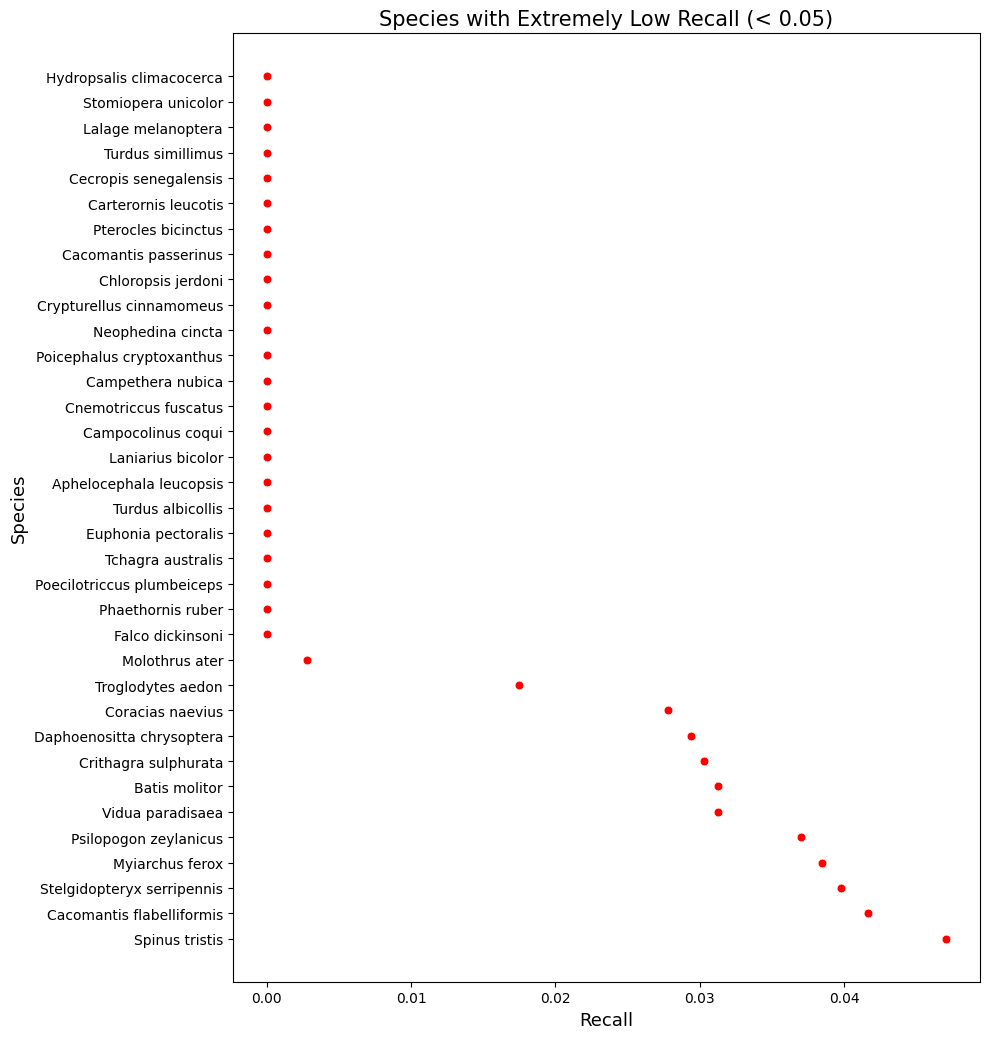

In [88]:
plt.figure(figsize=(10, len(recall_low) * 0.3))

sns.scatterplot(
    data=recall_low,
    x="recall",
    y="species_name",
    color="red",
    s=40
)

plt.title("Species with Extremely Low Recall (< 0.05)", fontsize=15)
plt.xlabel("Recall", fontsize=13)
plt.ylabel("Species", fontsize=13)
plt.tight_layout()
plt.show()


In [89]:
#Recall between 0.05 and 0.3 (Moderately Hard)
#The model gets them sometimes but still performs poorly.

recall_midlow = recall_df[
    (recall_df["recall"] >= 0.05) & (recall_df["recall"] < 0.30)
].sort_values("recall")

recall_midlow


,species_id,species_name,TP,FN,count,recall
39,39,Charadrius vociferus,20,367,387,0.051680
241,241,Granatina granatina,1,18,19,0.052632
96,96,Tangara cyanocephala,1,17,18,0.055556
83,83,Platysteira cyanea,1,16,17,0.058824
161,161,Petroica rosea,2,30,32,0.062500
...,...,...,...,...,...,...
133,133,Cossypha heuglini,17,42,59,0.288136
137,137,Saxicola caprata,29,71,100,0.290000
196,196,Megascops asio,109,264,373,0.292225
59,59,Anas gracilis,93,225,318,0.292453


In [90]:
recall_high = recall_df[recall_df["recall"] > 0.70].sort_values("recall", ascending=False)
recall_high


,species_id,species_name,TP,FN,count,recall
104,104,Phrygilus atriceps,22,0,22,1.000000
79,79,Dicrurus forficatus,26,0,26,1.000000
28,28,Phoebetria palpebrata,8,0,8,1.000000
283,283,Riccordia ricordii,41,1,42,0.976190
202,202,Pygoscelis antarcticus,25,1,26,0.961538
275,275,Theristicus branickii,19,1,20,0.950000
131,131,Turdus rufitorques,33,3,36,0.916667
264,264,Sittiparus varius,80,8,88,0.909091
212,212,Chaetops aurantius,10,1,11,0.909091
25,25,Spheniscus demersus,112,13,125,0.896000


We shall conduct a Per-Species Confusion Matrix (Binary) forr funsies, because our data was trained on the assumption of presence only data that a collection of binary classifiers (exist, not)

In [94]:
# True labels (species indices)
y_true = y_true_cols

# Predicted labels (species the model ranks #1)
y_pred = predicted_cols
